# M6b -- KNN Regressor | California Housing


**Dataset:** California Housing (built into sklearn -- no download needed)
**Problem:** Predict the median house value for California districts based on 8 features.

**Why a separate notebook for KNN Regressor:**
KNN Classifier and KNN Regressor share the same algorithm -- find K nearest neighbors -- but the output and evaluation are completely different. Classification returns a majority vote. Regression returns a mean. The challenges are also different: with 20,640 rows this dataset is large enough to show exactly where KNN starts to struggle computationally and in terms of accuracy.

**Why California Housing for this:**
House prices have a genuinely geographic structure -- districts near each other really do have similar prices. The Latitude and Longitude features make the nearest neighbor concept physically intuitive. A house in San Francisco has neighbors that are also in San Francisco, not in rural farmland. KNN can exploit this local structure directly.

**What this notebook covers:**
1. Dataset exploration including geographic visualization
2. How KNN Regressor makes predictions -- the mean of K neighbors
3. The effect of scale -- Population ranges 3 to 35682, MedInc ranges 0.5 to 15
4. Finding optimal K for regression
5. Effect of geographic features -- what happens when you include or exclude Latitude/Longitude
6. Comparing KNN Regressor against Linear Regression on the same data
7. Where KNN Regressor wins and where it fails


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    KFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print("Imports ready")

Imports ready


## 1. Load and Explore

In [2]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='MedHouseVal')

print(f"Shape: {X.shape}")
print(f"Target: Median House Value (in $100,000 units)")
print(f"  Min:    ${y.min()*100:.0f}k")
print(f"  Max:    ${y.max()*100:.0f}k")
print(f"  Mean:   ${y.mean()*100:.0f}k")
print(f"  Median: ${y.median()*100:.0f}k")
print()
print("Features:")
for col in X.columns:
    print(f"  {col:<15} min={X[col].min():>10.2f}  max={X[col].max():>10.2f}  mean={X[col].mean():>8.2f}")
print()
print("No missing values:", X.isnull().sum().sum() == 0)
print()
print("Note: MedInc is in tens of thousands USD, not raw dollars")
print("      Latitude and Longitude are actual GPS coordinates")

Shape: (20640, 8)
Target: Median House Value (in $100,000 units)
  Min:    $15k
  Max:    $500k
  Mean:   $207k
  Median: $180k

Features:
  MedInc          min=      0.50  max=     15.00  mean=    3.87
  HouseAge        min=      1.00  max=     52.00  mean=   28.64
  AveRooms        min=      0.85  max=    141.91  mean=    5.43
  AveBedrms       min=      0.33  max=     34.07  mean=    1.10
  Population      min=      3.00  max=  35682.00  mean= 1425.48
  AveOccup        min=      0.69  max=   1243.33  mean=    3.07
  Latitude        min=     32.54  max=     41.95  mean=   35.63
  Longitude       min=   -124.35  max=   -114.31  mean= -119.57

No missing values: True

Note: MedInc is in tens of thousands USD, not raw dollars
      Latitude and Longitude are actual GPS coordinates


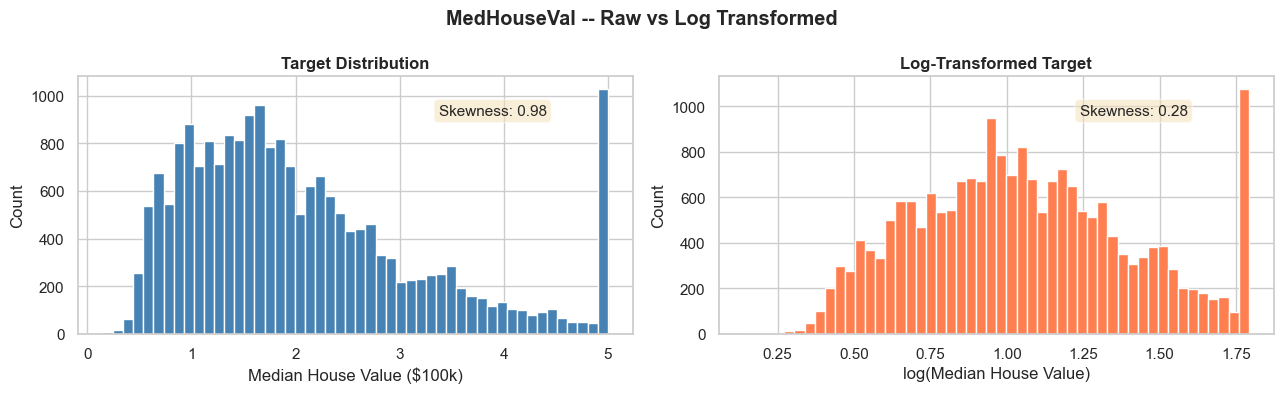

The target is capped at 5.0 ($500k) -- a data collection artifact.
Notice the spike at 5.0 -- many districts hit the ceiling.
We will work with raw values but log-transform is worth trying.


In [3]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution', fontweight='bold')
skew = y.skew()
axes[0].text(0.65, 0.85, f'Skewness: {skew:.2f}',
             transform=axes[0].transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1].hist(np.log1p(y), bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('log(Median House Value)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-Transformed Target', fontweight='bold')
skew_log = np.log1p(y).skew()
axes[1].text(0.65, 0.85, f'Skewness: {skew_log:.2f}',
             transform=axes[1].transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('MedHouseVal -- Raw vs Log Transformed', fontweight='bold')
plt.tight_layout()
plt.show()

print("The target is capped at 5.0 ($500k) -- a data collection artifact.")
print("Notice the spike at 5.0 -- many districts hit the ceiling.")
print("We will work with raw values but log-transform is worth trying.")

## 2. Geographic Visualization

This dataset has Latitude and Longitude -- we can plot actual California geography and see the price patterns spatially.

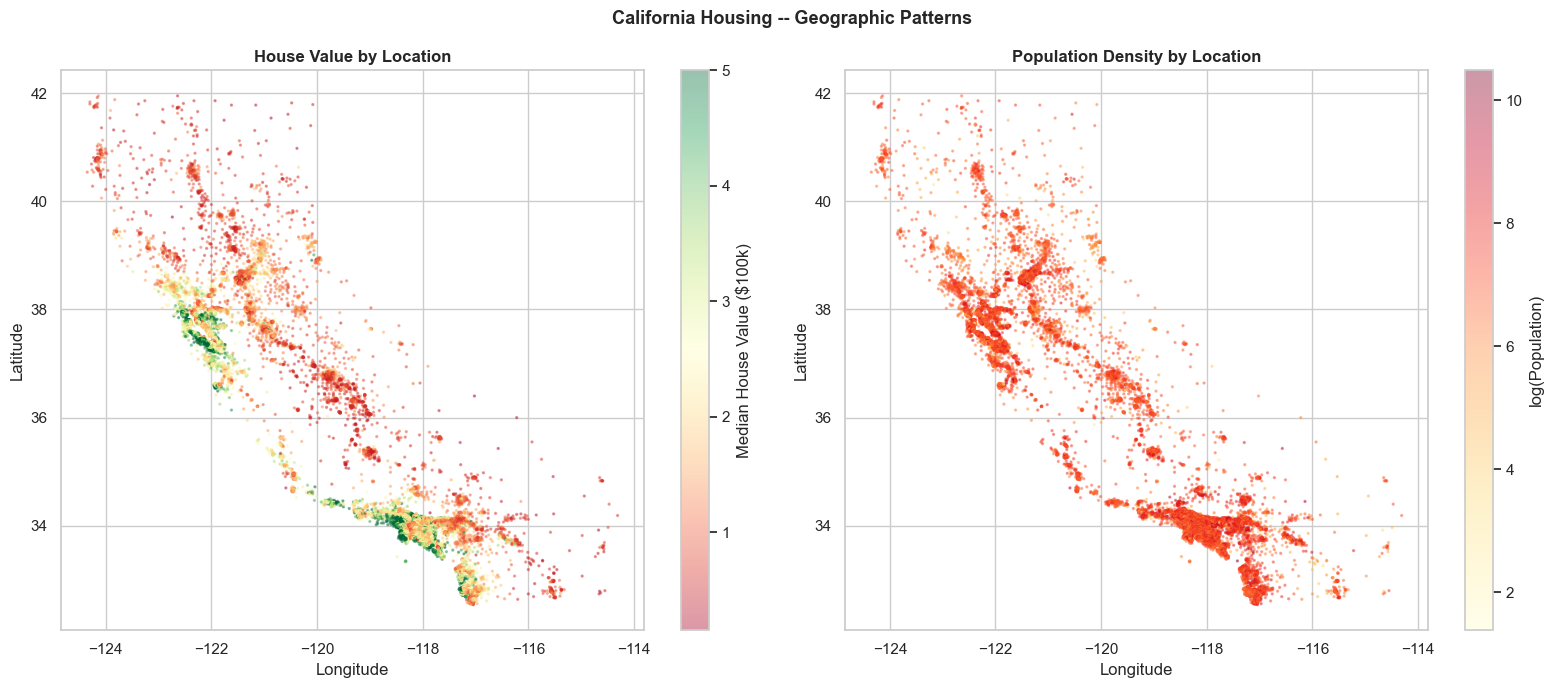

Key geographic observations:
  San Francisco Bay Area (lat ~37.5, long ~-122): highest prices
  Los Angeles (lat ~34, long ~-118): high prices, high population
  Central Valley (long ~-120): low prices, high population (agriculture)
  Coast vs inland: coastal districts consistently more expensive

KNN should exploit this geographic structure naturally --
nearest neighbors in lat/lon space are physically nearby districts.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# House value by location
sc1 = axes[0].scatter(X['Longitude'], X['Latitude'],
                       c=y, cmap='RdYlGn',
                       s=2, alpha=0.4)
plt.colorbar(sc1, ax=axes[0], label='Median House Value ($100k)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('House Value by Location', fontweight='bold')

# Population density by location
sc2 = axes[1].scatter(X['Longitude'], X['Latitude'],
                       c=np.log1p(X['Population']),
                       cmap='YlOrRd',
                       s=2, alpha=0.4)
plt.colorbar(sc2, ax=axes[1], label='log(Population)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Population Density by Location', fontweight='bold')

plt.suptitle('California Housing -- Geographic Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key geographic observations:")
print("  San Francisco Bay Area (lat ~37.5, long ~-122): highest prices")
print("  Los Angeles (lat ~34, long ~-118): high prices, high population")
print("  Central Valley (long ~-120): low prices, high population (agriculture)")
print("  Coast vs inland: coastal districts consistently more expensive")
print()
print("KNN should exploit this geographic structure naturally --")
print("nearest neighbors in lat/lon space are physically nearby districts.")

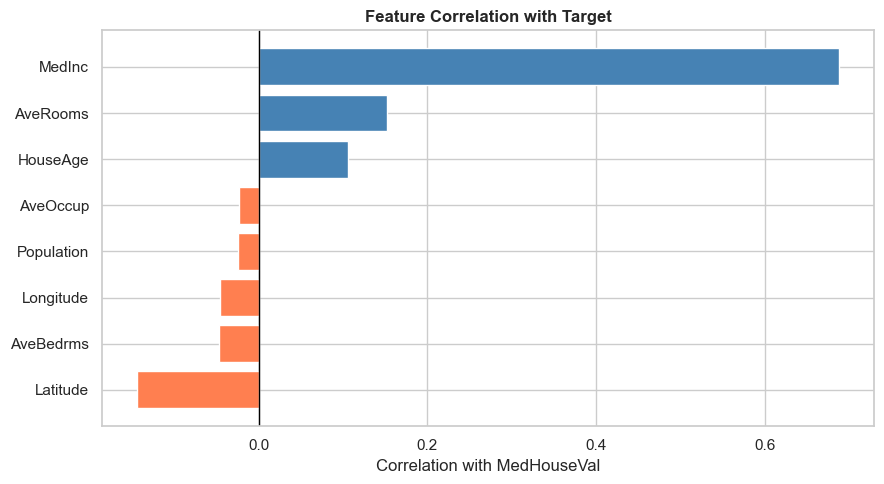

Feature correlations with house value:
  MedInc           0.6881  (positive)
  AveRooms         0.1519  (positive)
  HouseAge         0.1056  (positive)
  AveOccup        -0.0237  (negative)
  Population      -0.0246  (negative)
  Longitude       -0.0460  (negative)
  AveBedrms       -0.0467  (negative)
  Latitude        -0.1442  (negative)


In [5]:
# Correlation with target
corr = X.corrwith(y).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
colors = ['steelblue' if v > 0 else 'coral' for v in corr.values]
plt.barh(corr.index, corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Correlation with MedHouseVal')
plt.title('Feature Correlation with Target', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Feature correlations with house value:")
for feat, val in corr.items():
    direction = "positive" if val > 0 else "negative"
    print(f"  {feat:<15} {val:>7.4f}  ({direction})")

## 3. How KNN Regressor Works

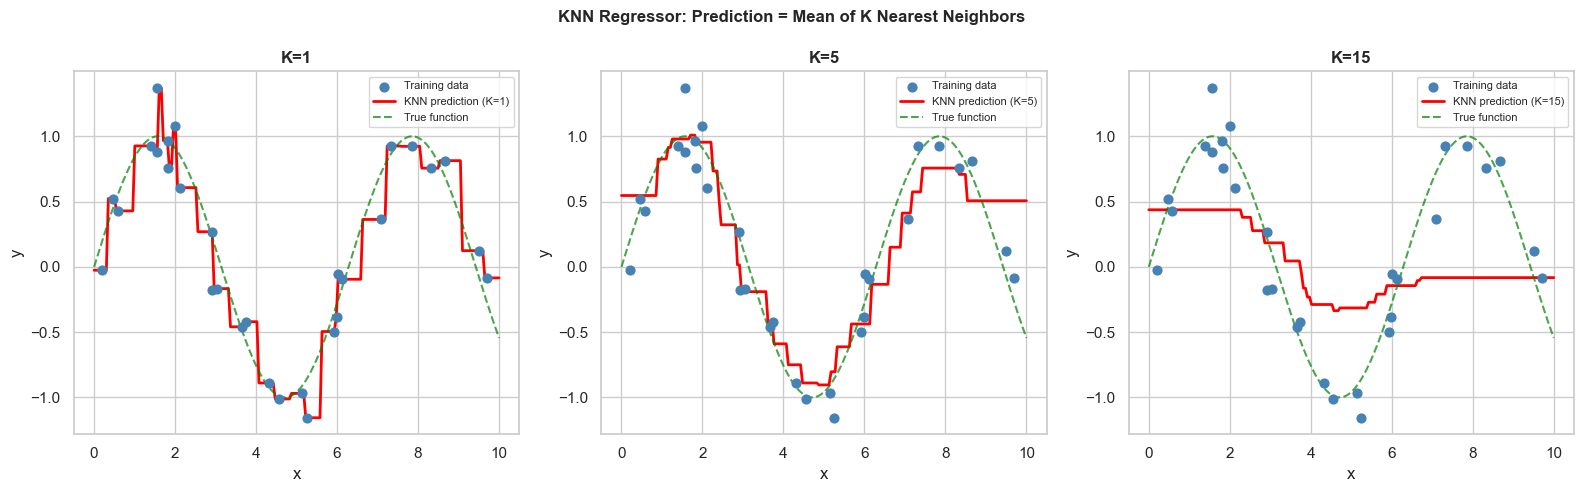

K=1:  prediction passes through every training point -- extreme overfitting
K=5:  smoother, follows the general trend -- good balance
K=15: very smooth, may miss local patterns -- underfitting

The prediction at any point x is the arithmetic mean of the
target values of the K closest training points.


In [6]:
# Demonstrate manually on a small subset -- 1D example first
np.random.seed(42)
n_demo = 30
x_demo = np.sort(np.random.uniform(0, 10, n_demo))
y_demo = np.sin(x_demo) + np.random.normal(0, 0.2, n_demo)

x_plot = np.linspace(0, 10, 200)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, k in zip(axes, [1, 5, 15]):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(x_demo.reshape(-1, 1), y_demo)
    y_plot = knn.predict(x_plot.reshape(-1, 1))

    ax.scatter(x_demo, y_demo, color='steelblue', s=40, zorder=3, label='Training data')
    ax.plot(x_plot, y_plot, color='red', linewidth=2, label=f'KNN prediction (K={k})')
    ax.plot(x_plot, np.sin(x_plot), color='green', linewidth=1.5,
            linestyle='--', alpha=0.7, label='True function')
    ax.set_title(f'K={k}', fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8)

plt.suptitle('KNN Regressor: Prediction = Mean of K Nearest Neighbors',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("K=1:  prediction passes through every training point -- extreme overfitting")
print("K=5:  smoother, follows the general trend -- good balance")
print("K=15: very smooth, may miss local patterns -- underfitting")
print()
print("The prediction at any point x is the arithmetic mean of the")
print("target values of the K closest training points.")

In [7]:
# Manual demonstration on real data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Pick one test point
test_idx = 0
test_point = X_test_sc[test_idx]
true_value = y_test.iloc[test_idx]

# Compute distances manually
distances = np.sqrt(np.sum((X_train_sc - test_point)**2, axis=1))

K = 5
nearest_idx  = np.argsort(distances)[:K]
nearest_vals = y_train.iloc[nearest_idx].values
nearest_dists = distances[nearest_idx]

print(f"Manual KNN Regression for one test district:")
print(f"  True median house value: ${true_value*100:.1f}k")
print()
print(f"  {K} nearest training districts:")
for i, (val, dist) in enumerate(zip(nearest_vals, nearest_dists)):
    print(f"    Neighbor {i+1}: value=${val*100:.1f}k  distance={dist:.4f}")

prediction = nearest_vals.mean()
print()
print(f"  Prediction (mean of neighbors): ${prediction*100:.1f}k")
print(f"  Error: ${abs(prediction - true_value)*100:.1f}k")

Manual KNN Regression for one test district:
  True median house value: $47.7k

  5 nearest training districts:
    Neighbor 1: value=$47.6k  distance=0.3239
    Neighbor 2: value=$40.9k  distance=0.3477
    Neighbor 3: value=$57.6k  distance=0.3620
    Neighbor 4: value=$42.5k  distance=0.4159
    Neighbor 5: value=$60.8k  distance=0.4396

  Prediction (mean of neighbors): $49.9k
  Error: $2.2k


## 4. Why Scaling is Critical -- Feature Range Problem

In [8]:
# Population ranges from 3 to 35682
# MedInc ranges from 0.5 to 15
# Without scaling, Population completely dominates distance calculations

pipe_unscaled = Pipeline([
    ('model', KNeighborsRegressor(n_neighbors=5))
])
pipe_unscaled.fit(X_train, y_train)
rmse_unscaled = np.sqrt(mean_squared_error(y_test, pipe_unscaled.predict(X_test)))

pipe_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=5))
])
pipe_scaled.fit(X_train, y_train)
rmse_scaled = np.sqrt(mean_squared_error(y_test, pipe_scaled.predict(X_test)))

print("Effect of scaling on KNN Regressor (K=5):")
print(f"  Without scaling: RMSE = {rmse_unscaled:.4f}")
print(f"  With scaling:    RMSE = {rmse_scaled:.4f}")
print(f"  Improvement:     {(rmse_unscaled - rmse_scaled)/rmse_unscaled*100:.1f}%")
print()
print("Without scaling, Population (range ~35000) dominates every distance.")
print("Two districts with identical house prices but different populations")
print("appear far apart -- the model treats them as unrelated.")
print()
print("Feature ranges (unscaled):")
for col in X.columns:
    r = X[col].max() - X[col].min()
    print(f"  {col:<15} range = {r:>10.2f}")

Effect of scaling on KNN Regressor (K=5):
  Without scaling: RMSE = 1.0577
  With scaling:    RMSE = 0.6576
  Improvement:     37.8%

Without scaling, Population (range ~35000) dominates every distance.
Two districts with identical house prices but different populations
appear far apart -- the model treats them as unrelated.

Feature ranges (unscaled):
  MedInc          range =      14.50
  HouseAge        range =      51.00
  AveRooms        range =     141.06
  AveBedrms       range =      33.73
  Population      range =   35679.00
  AveOccup        range =    1242.64
  Latitude        range =       9.41
  Longitude       range =      10.04


## 5. Finding Optimal K

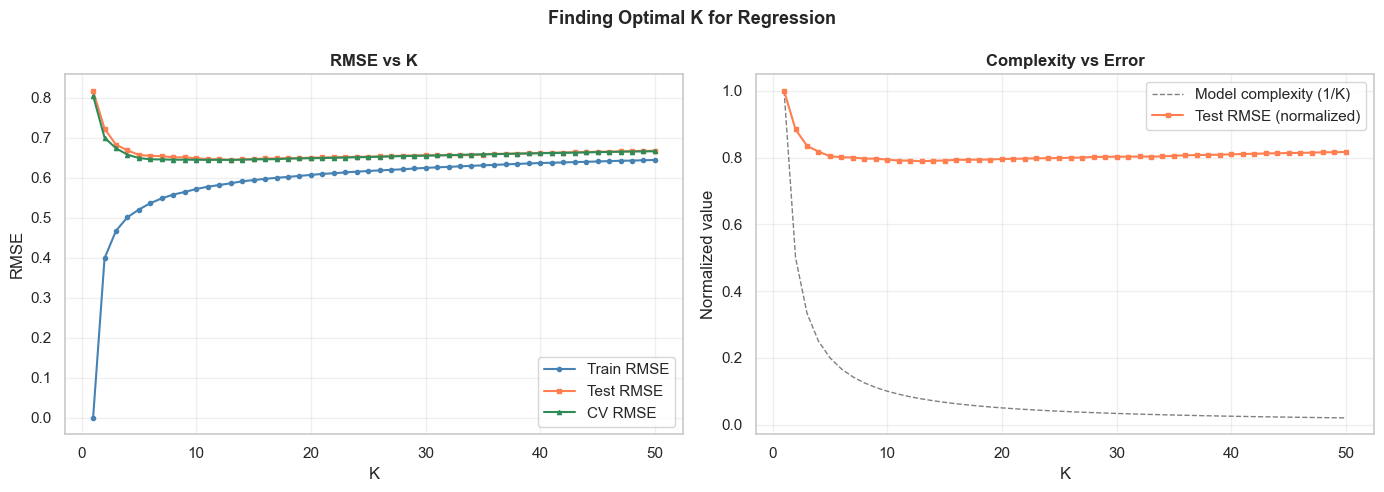

Best K by CV RMSE:   13   (CV RMSE=0.6452)
Best K by test RMSE: 13   (test RMSE=0.6452)

Use CV RMSE to select K -- not test RMSE.
Using test RMSE leaks test information into the model selection process.


In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
k_values = range(1, 51)
train_rmse, test_rmse, cv_rmse = [], [], []

for k in k_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, pipe.predict(X_train))))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, pipe.predict(X_test))))
    cv = -cross_val_score(pipe, X_train, y_train, cv=3,
                           scoring='neg_root_mean_squared_error').mean()
    cv_rmse.append(cv)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, train_rmse, 'o-', color='steelblue', markersize=3, label='Train RMSE')
axes[0].plot(k_values, test_rmse,  's-', color='coral',     markersize=3, label='Test RMSE')
axes[0].plot(k_values, cv_rmse,    '^-', color='seagreen',  markersize=3, label='CV RMSE')
axes[0].set_xlabel('K')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE vs K', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, [1/k for k in k_values], '--', color='gray',
             linewidth=1, label='Model complexity (1/K)')
axes[1].plot(k_values, [r/max(test_rmse) for r in test_rmse],
             's-', color='coral', markersize=3, label='Test RMSE (normalized)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Normalized value')
axes[1].set_title('Complexity vs Error', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Finding Optimal K for Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = k_values[np.argmin(cv_rmse)]
print(f"Best K by CV RMSE:   {best_k}   (CV RMSE={min(cv_rmse):.4f})")
print(f"Best K by test RMSE: {k_values[np.argmin(test_rmse)]}   (test RMSE={min(test_rmse):.4f})")
print()
print("Use CV RMSE to select K -- not test RMSE.")
print("Using test RMSE leaks test information into the model selection process.")

## 6. Effect of Geographic Features

Latitude and Longitude contain rich local structure. This section shows what happens when you include or exclude them.

In [10]:
feature_sets = {
    'All features':              X.columns.tolist(),
    'No Lat/Long':               [c for c in X.columns if c not in ['Latitude', 'Longitude']],
    'Lat/Long only':             ['Latitude', 'Longitude'],
    'Geographic + Income':       ['Latitude', 'Longitude', 'MedInc'],
}

pipe_geo = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=best_k))
])

print(f"{'Feature Set':<28} {'Test RMSE':>10} {'R-squared':>10}")
print("-" * 50)

geo_results = {}
for name, feats in feature_sets.items():
    pipe_geo.fit(X_train[feats], y_train)
    pred = pipe_geo.predict(X_test[feats])
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    geo_results[name] = {'rmse': rmse, 'r2': r2}
    print(f"{name:<28} {rmse:>10.4f} {r2:>10.4f}")

print()
print("Key insight: Latitude and Longitude alone are surprisingly powerful.")
print("This confirms that geographic location is one of the strongest")
print("predictors of house price -- even more so for KNN than for Linear Regression,")
print("because KNN directly exploits local spatial clusters.")

Feature Set                   Test RMSE  R-squared
--------------------------------------------------
All features                     0.6452     0.6823
No Lat/Long                      0.7203     0.6041
Lat/Long only                    0.5273     0.7878
Geographic + Income              0.5790     0.7442

Key insight: Latitude and Longitude alone are surprisingly powerful.
This confirms that geographic location is one of the strongest
predictors of house price -- even more so for KNN than for Linear Regression,
because KNN directly exploits local spatial clusters.


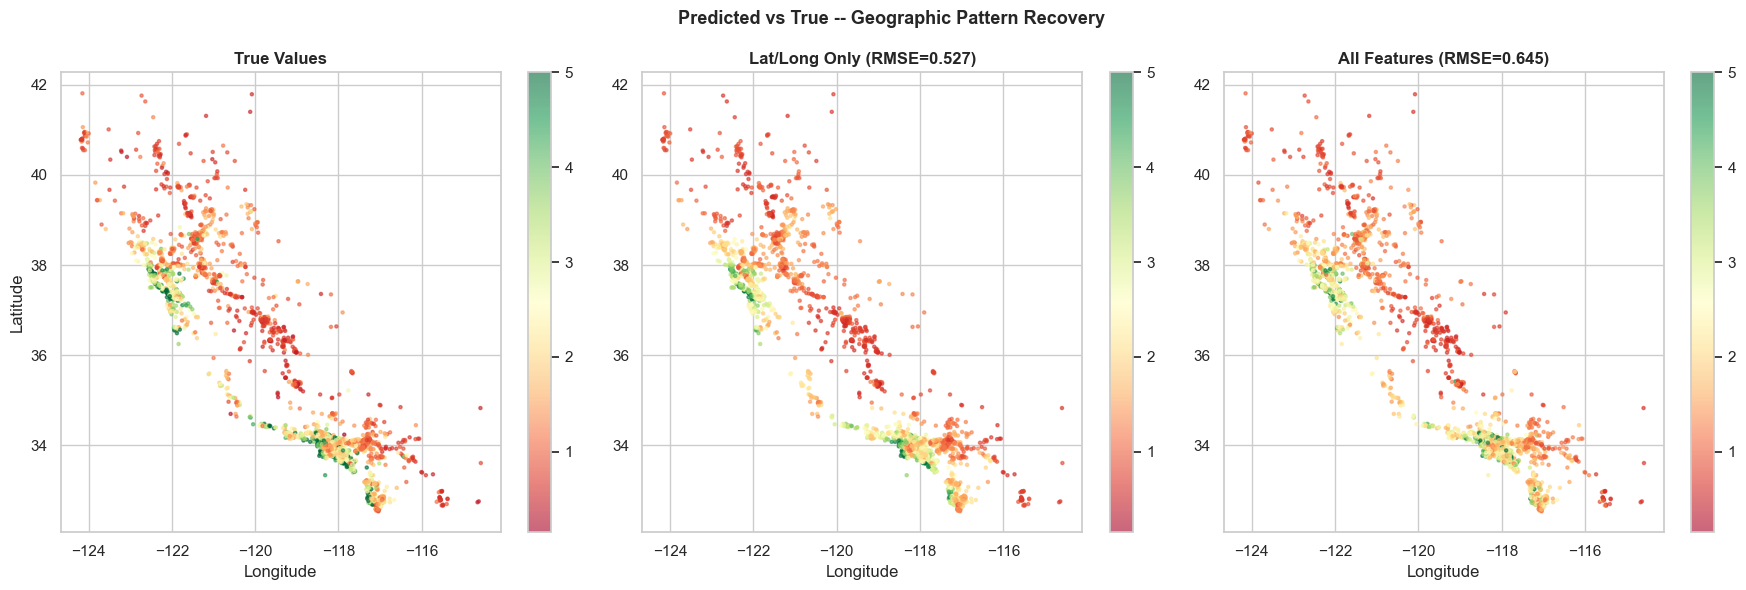

In [11]:
# Visualize -- predictions using Lat/Long only vs all features
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# True values
sc0 = axes[0].scatter(X_test['Longitude'], X_test['Latitude'],
                       c=y_test, cmap='RdYlGn', s=5, alpha=0.6,
                       vmin=y.min(), vmax=y.max())
plt.colorbar(sc0, ax=axes[0])
axes[0].set_title('True Values', fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Predictions: Lat/Long only
pipe_geo.fit(X_train[['Latitude','Longitude']], y_train)
pred_geo = pipe_geo.predict(X_test[['Latitude','Longitude']])
sc1 = axes[1].scatter(X_test['Longitude'], X_test['Latitude'],
                       c=pred_geo, cmap='RdYlGn', s=5, alpha=0.6,
                       vmin=y.min(), vmax=y.max())
plt.colorbar(sc1, ax=axes[1])
rmse_geo = np.sqrt(mean_squared_error(y_test, pred_geo))
axes[1].set_title(f'Lat/Long Only (RMSE={rmse_geo:.3f})', fontweight='bold')
axes[1].set_xlabel('Longitude')

# Predictions: all features
pipe_geo.fit(X_train, y_train)
pred_all = pipe_geo.predict(X_test)
sc2 = axes[2].scatter(X_test['Longitude'], X_test['Latitude'],
                       c=pred_all, cmap='RdYlGn', s=5, alpha=0.6,
                       vmin=y.min(), vmax=y.max())
plt.colorbar(sc2, ax=axes[2])
rmse_all = np.sqrt(mean_squared_error(y_test, pred_all))
axes[2].set_title(f'All Features (RMSE={rmse_all:.3f})', fontweight='bold')
axes[2].set_xlabel('Longitude')

plt.suptitle('Predicted vs True -- Geographic Pattern Recovery',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. GridSearchCV -- Full Tuning

In [12]:
param_grid = {
    'model__n_neighbors': [3, 5, 7, 10, 15, 20, 30],
    'model__weights':     ['uniform', 'distance'],
    'model__metric':      ['euclidean', 'manhattan'],
    'model__p':           [1, 2],
}

# Note: p parameter only applies when metric='minkowski'
# We simplify to avoid redundancy
param_grid = {
    'model__n_neighbors': [3, 5, 7, 10, 15, 20, 30],
    'model__weights':     ['uniform', 'distance'],
    'model__metric':      ['euclidean', 'manhattan'],
}

pipe_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor())
])

gs = GridSearchCV(
    pipe_gs, param_grid,
    cv=kf, scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
gs.fit(X_train, y_train)

print(f"Best parameters: {gs.best_params_}")
print(f"Best CV RMSE:    {-gs.best_score_:.4f}")

Best parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 10, 'model__weights': 'distance'}
Best CV RMSE:    0.6010


In [13]:
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=== Tuned KNN Regressor Results ===")
print(f"RMSE:      {rmse:.4f}  (in $100k units)")
print(f"MAE:       {mae:.4f}")
print(f"R-squared: {r2:.4f}")
print()

dollar_mae = mae * 100000
print(f"MAE in dollars: ${dollar_mae:,.0f}  (average prediction error)")

=== Tuned KNN Regressor Results ===
RMSE:      0.6050  (in $100k units)
MAE:       0.4067
R-squared: 0.7207

MAE in dollars: $40,673  (average prediction error)


## 8. Actual vs Predicted and Residuals

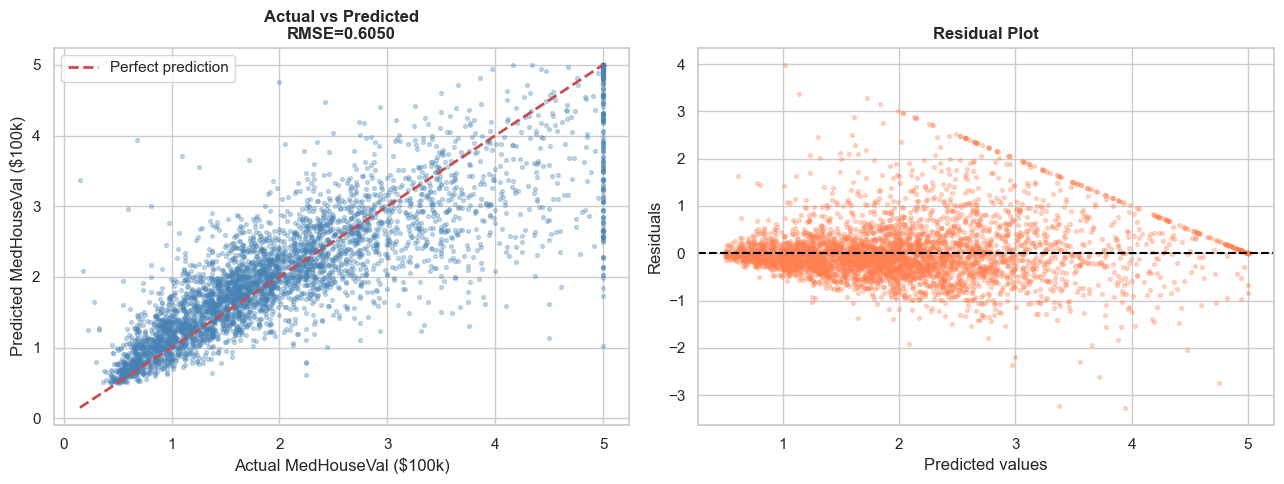

Residual mean: 0.01410  (should be near zero)
Residual std:  0.60489

Notice the cluster of points at actual=5.0 -- these are the capped values.
The model struggles to predict exactly 5.0 because the cap creates
an artificial spike in the target distribution.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual MedHouseVal ($100k)')
axes[0].set_ylabel('Predicted MedHouseVal ($100k)')
axes[0].set_title(f'Actual vs Predicted\nRMSE={rmse:.4f}', fontweight='bold')
axes[0].legend()

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=8, color='coral')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.5f}  (should be near zero)")
print(f"Residual std:  {residuals.std():.5f}")
print()
print("Notice the cluster of points at actual=5.0 -- these are the capped values.")
print("The model struggles to predict exactly 5.0 because the cap creates")
print("an artificial spike in the target distribution.")

## 9. KNN Regressor vs Ridge Regression -- Head to Head

In [15]:
# Ridge Regression on same data
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae  = mean_absolute_error(y_test, ridge_pred)
ridge_r2   = r2_score(y_test, ridge_pred)

ridge_cv = -cross_val_score(ridge, X, y, cv=kf,
                              scoring='neg_root_mean_squared_error')
knn_cv   = -cross_val_score(best_model, X, y, cv=kf,
                              scoring='neg_root_mean_squared_error')

print("=" * 55)
print("  KNN Regressor vs Ridge -- California Housing")
print("=" * 55)
print(f"{'Metric':<18} {'KNN Regressor':>16} {'Ridge':>16}")
print("-" * 55)
metrics = [
    ('Test RMSE',  rmse,       ridge_rmse),
    ('Test MAE',   mae,        ridge_mae),
    ('R-squared',  r2,         ridge_r2),
    ('CV RMSE',    knn_cv.mean(), ridge_cv.mean()),
    ('CV Std',     knn_cv.std(),  ridge_cv.std()),
]
for name, knn_val, ridge_val in metrics:
    better = '<--' if (knn_val < ridge_val and name != 'R-squared') or                       (knn_val > ridge_val and name == 'R-squared') else '   '
    worse  = '<--' if (ridge_val < knn_val and name != 'R-squared') or                       (ridge_val > knn_val and name == 'R-squared') else '   '
    print(f"{name:<18} {knn_val:>16.4f}{better} {ridge_val:>14.4f}{worse}")

print()
if knn_cv.mean() < ridge_cv.mean():
    print("KNN Regressor wins on CV RMSE.")
    print("The local geographic structure gives KNN an advantage over the global linear model.")
else:
    print("Ridge Regression wins on CV RMSE.")
    print("The relationship between features and price is sufficiently linear that")
    print("a global model outperforms local averaging.")

  KNN Regressor vs Ridge -- California Housing
Metric                KNN Regressor            Ridge
-------------------------------------------------------
Test RMSE                    0.6050<--         0.7456   
Test MAE                     0.4067<--         0.5332   
R-squared                    0.7207<--         0.5758   
CV RMSE                      0.5895<--         0.7282   
CV Std                       0.0193            0.0149<--

KNN Regressor wins on CV RMSE.
The local geographic structure gives KNN an advantage over the global linear model.


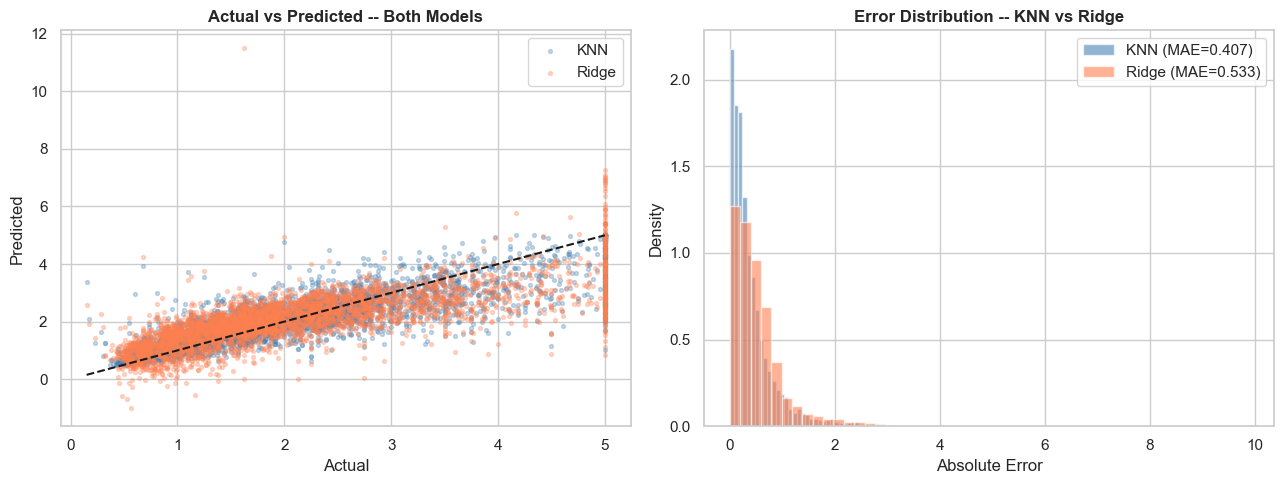

In [16]:
# Residual comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color='steelblue', label='KNN')
axes[0].scatter(y_test, ridge_pred, alpha=0.3, s=8, color='coral', label='Ridge')
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'k--', linewidth=1.5)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted -- Both Models', fontweight='bold')
axes[0].legend()

# Error distribution
knn_errors   = np.abs(y_test - y_pred)
ridge_errors = np.abs(y_test - ridge_pred)
axes[1].hist(knn_errors,   bins=50, alpha=0.6, color='steelblue',
             label=f'KNN (MAE={mae:.3f})', density=True)
axes[1].hist(ridge_errors, bins=50, alpha=0.6, color='coral',
             label=f'Ridge (MAE={ridge_mae:.3f})', density=True)
axes[1].set_xlabel('Absolute Error')
axes[1].set_ylabel('Density')
axes[1].set_title('Error Distribution -- KNN vs Ridge', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Computational Cost -- KNN at Scale

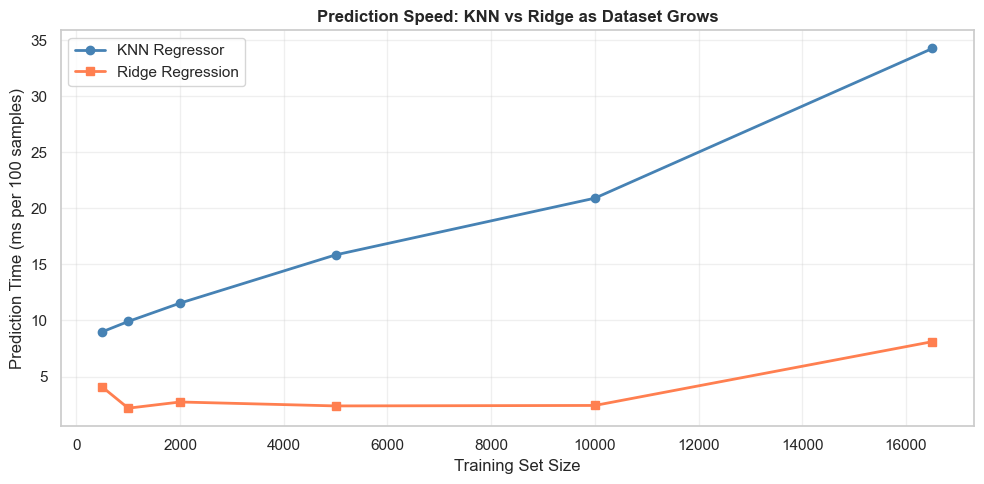

Training set sizes tested: [500, 1000, 2000, 5000, 10000, 16512]

  Training Size     KNN (ms)   Ridge (ms)  KNN / Ridge
-------------------------------------------------------
            500         9.00         4.06          2.2x slower
           1000         9.91         2.18          4.5x slower
           2000        11.55         2.73          4.2x slower
           5000        15.85         2.38          6.7x slower
          10000        20.91         2.42          8.6x slower
          16512        34.26         8.12          4.2x slower

Ridge prediction time is essentially constant regardless of training size.
KNN prediction time grows linearly -- it must scan all training points.
At full dataset size, KNN is significantly slower per prediction.


In [17]:
# KNN prediction cost grows linearly with training set size
# This is the core practical limitation

subset_sizes = [500, 1000, 2000, 5000, 10000, len(X_train)]
predict_times_knn   = []
predict_times_ridge = []

knn_timing = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=best_k))
])

for n in subset_sizes:
    X_sub = X_train.iloc[:n]
    y_sub = y_train.iloc[:n]

    # KNN timing
    knn_timing.fit(X_sub, y_sub)
    start = time.time()
    for _ in range(10):
        knn_timing.predict(X_test.iloc[:100])
    knn_t = (time.time() - start) / 10 * 1000
    predict_times_knn.append(knn_t)

    # Ridge timing
    ridge_tmp = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])
    ridge_tmp.fit(X_sub, y_sub)
    start = time.time()
    for _ in range(10):
        ridge_tmp.predict(X_test.iloc[:100])
    ridge_t = (time.time() - start) / 10 * 1000
    predict_times_ridge.append(ridge_t)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(subset_sizes, predict_times_knn,   'o-', color='steelblue',
        linewidth=2, label='KNN Regressor')
ax.plot(subset_sizes, predict_times_ridge, 's-', color='coral',
        linewidth=2, label='Ridge Regression')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Prediction Time (ms per 100 samples)')
ax.set_title('Prediction Speed: KNN vs Ridge as Dataset Grows', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Training set sizes tested:", subset_sizes)
print()
print(f"{'Training Size':>15} {'KNN (ms)':>12} {'Ridge (ms)':>12} {'KNN / Ridge':>12}")
print("-" * 55)
for n, kt, rt in zip(subset_sizes, predict_times_knn, predict_times_ridge):
    ratio = kt / rt if rt > 0 else float('inf')
    print(f"{n:>15} {kt:>12.2f} {rt:>12.2f} {ratio:>12.1f}x slower")

print()
print("Ridge prediction time is essentially constant regardless of training size.")
print("KNN prediction time grows linearly -- it must scan all training points.")
print("At full dataset size, KNN is significantly slower per prediction.")

In [18]:
# Training time comparison
train_times_knn   = []
train_times_ridge = []

for n in subset_sizes:
    X_sub = X_train.iloc[:n]
    y_sub = y_train.iloc[:n]

    # KNN train time
    knn_tr = Pipeline([('scaler', StandardScaler()),
                        ('model', KNeighborsRegressor(n_neighbors=best_k))])
    start = time.time()
    knn_tr.fit(X_sub, y_sub)
    train_times_knn.append((time.time() - start) * 1000)

    # Ridge train time
    ridge_tr = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])
    start = time.time()
    ridge_tr.fit(X_sub, y_sub)
    train_times_ridge.append((time.time() - start) * 1000)

print("Training times (ms):")
print(f"{'Training Size':>15} {'KNN (ms)':>12} {'Ridge (ms)':>12}")
print("-" * 42)
for n, kt, rt in zip(subset_sizes, train_times_knn, train_times_ridge):
    print(f"{n:>15} {kt:>12.2f} {rt:>12.2f}")
print()
print("KNN training is near-instant -- it just stores the data.")
print("Ridge training increases with dataset size due to matrix operations.")
print("The tradeoff: KNN pays at prediction time, Ridge pays at training time.")

Training times (ms):
  Training Size     KNN (ms)   Ridge (ms)
------------------------------------------
            500        11.05        10.19
           1000         7.44         8.41
           2000        25.49         8.02
           5000        24.64        17.92
          10000        40.16        16.81
          16512        74.12        19.23

KNN training is near-instant -- it just stores the data.
Ridge training increases with dataset size due to matrix operations.
The tradeoff: KNN pays at prediction time, Ridge pays at training time.


## Summary

Prediction mechanism: the mean of the K nearest neighbors' target values. No learned parameters, no optimization, just memory and distance.

**Where KNN Regressor wins:**
- Data with strong local structure -- geographically clustered data, time series neighborhoods
- Non-linear relationships that linear models cannot capture
- Small datasets where computational cost is not a concern
- Problems where you can explain "similar inputs should give similar outputs" intuitively

**Where KNN Regressor loses:**
- Large datasets -- prediction cost is O(n) per sample
- High-dimensional feature spaces -- the curse of dimensionality degrades distance metrics
- Extrapolation -- KNN cannot predict outside the range of the training data at all
- Noisy data -- outlier neighbors directly corrupt the mean prediction

**Key practical rules:**
- Always scale features -- unscaled KNN is essentially random
- Select K using cross-validation, never test set performance
- Use weights='distance' when you expect very close neighbors to be far more informative than distant ones
- Consider Manhattan distance when features have different units or outliers are present

**The California Housing lesson:**
Geography matters enormously for house prices. KNN exploits local spatial clusters that a global linear model cannot capture. The Latitude/Longitude features alone give KNN surprising predictive power -- a direct consequence of the nearest neighbor concept matching the physical reality of real estate markets.
